<html> <h1 style="font-style:italic; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-7 </h1> </html>


<html> <h2 style="font-style:italic; color:blue;"> Transfer Learning </h2> </html>



<html> <h3 style="font-style:italic; color:blue;"> CIFAR10 Transfer Learning based Classifier </h3> </html>


<html> <h3 style="font-style:italic; color:blue;"> VGG16 and VGG19</h3> </html>


##### This notebook outlines the steps to build a classifier to leverage concepts of Transfer Learning by utilising a pretrained Deep-CNNs.


<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

In [1]:
# For Google Colab only!

!cat /proc/driver/nvidia/gpus/0000:00:04.0/information

Model: 		 Tesla T4
IRQ:   		 11
GPU UUID: 	 GPU-56eba2d9-7889-fd1c-1713-0f664d1d9f89
Video BIOS: 	 90.04.a7.00.01
Bus Type: 	 PCI
DMA Size: 	 47 bits
DMA Mask: 	 0x7fffffffffff
Bus Location: 	 0000:00:04.0
Device Minor: 	 0
GPU Firmware: 	 580.82.07
GPU Excluded:	 No



### Restart the Kernel

_________________________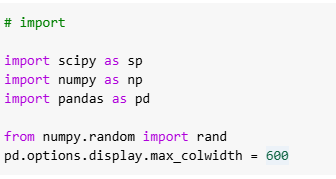

In [2]:
import scipy as sp
import numpy as np
import pandas as pd

from numpy.random import rand

pd.options.display.max_colwidth = 600

___________________________________________________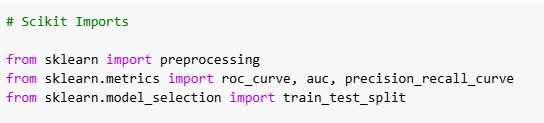

In [3]:
from sklearn import preprocessing
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split

__________________________________________________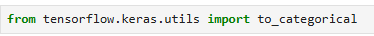

In [4]:
from tensorflow.keras.utils import to_categorical

___________________________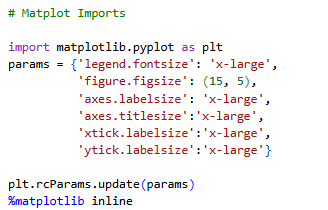

In [5]:
#

______________________________________________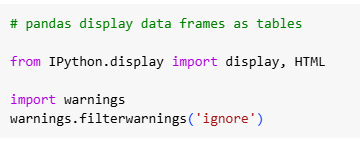

In [6]:
from IPython.display import display, HTML

import warnings
warnings.filterwarnings('ignore')

_________________________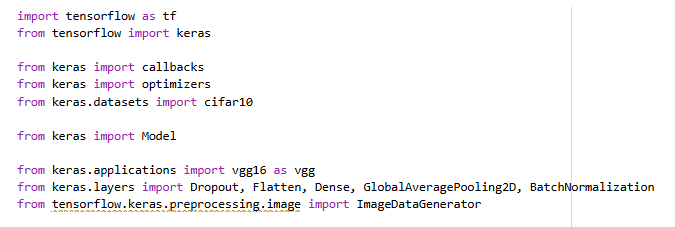

In [7]:
import tensorflow as tf
from tensorflow import keras

from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10

from keras import Model

from keras.applications import vgg16 as vgg
from keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Load and manipulate the DataSet

____________________________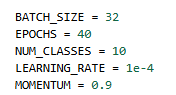

In [8]:
BATCH_SIZE = 32
EPOCHS = 40
NUM_CLASSES = 10
LEARNING_RATE = 1e-4
MOMENTUM = 0.9

__________________________________________________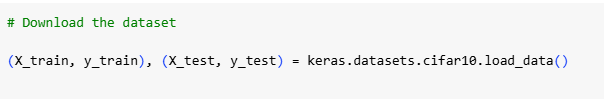

In [9]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

__________________________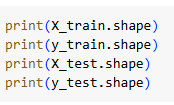

In [10]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


______________________________________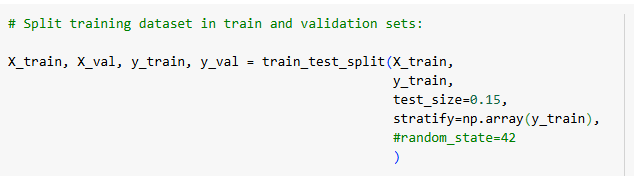

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    stratify=np.array(y_train),
    random_state=42
)

______________________________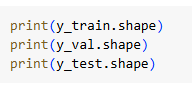

In [12]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(42500, 1)
(7500, 1)
(10000, 1)


Checks for free memory:

_____________________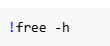

In [13]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.6Gi       8.4Gi       4.0Mi       2.7Gi        10Gi
Swap:             0B          0B          0B


______________________________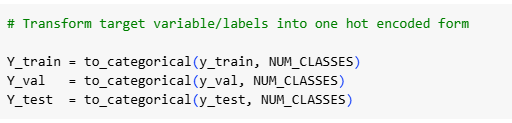

In [14]:
Y_train = to_categorical(y_train, NUM_CLASSES)
Y_val = to_categorical(y_val, NUM_CLASSES)
Y_test = to_categorical(y_test, NUM_CLASSES)

____________________________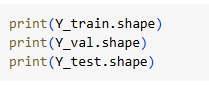

In [15]:
print(Y_train.shape)
print(Y_val.shape)
print(Y_test.shape)

(42500, 10)
(7500, 10)
(10000, 10)


### Preprocessing

In [16]:
# Since we are about to use VGG16 and VGG19as a feature extractor, the minimum size of an image its take is 48x48.
# We utilize ```scipy`` to resize images to required dimensions


_______________________________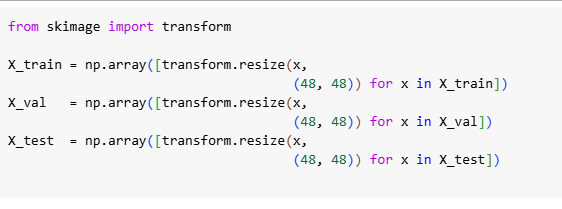

In [17]:
from skimage import transform

X_train = np.array([transform.resize(x, (48, 48)) for x in X_train])
X_val = np.array([transform.resize(x, (48, 48)) for x in X_val])
X_test = np.array([transform.resize(x, (48, 48)) for x in X_test])

_____________________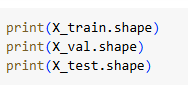

In [18]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(42500, 48, 48, 3)
(7500, 48, 48, 3)
(10000, 48, 48, 3)


____________________________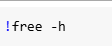

In [19]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       6.0Gi       3.9Gi       4.0Mi       2.7Gi       6.4Gi
Swap:             0B          0B          0B


# Create VGG19 Model

- Load VGG16 without the top classification layer
- Create a custom classifier
- Stack both models on top of each other


_______________________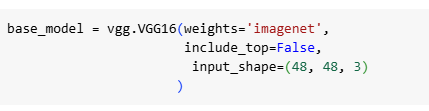

In [20]:
base_model = vgg.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)

base_model.trainable = False

____________________________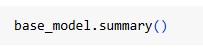

In [21]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

________________________________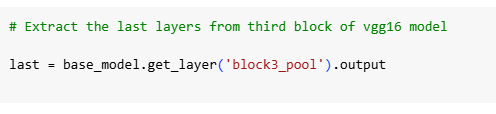

In [22]:
last = base_model.get_layer('block3_pool').output

______________________________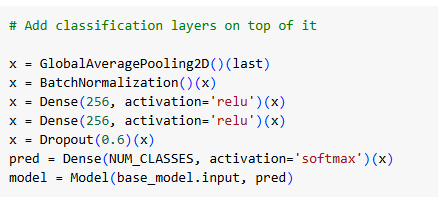

In [23]:
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.6)(x)

pred = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=pred)

____________________________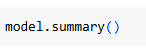

In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,870,666 (7.14 MB)

 Trainable params: 134,666 (526.04 KB)

 Non-trainable params: 1,736,000 (6.62 MB)

_____________________________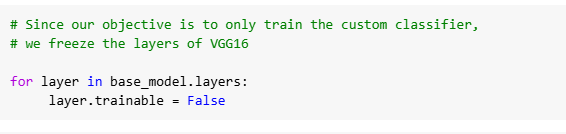

In [25]:
for layer in base_model.layers:
    layer.trainable = False

_________________________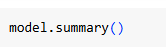

In [26]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,870,666 (7.14 MB)

 Trainable params: 134,666 (526.04 KB)

 Non-trainable params: 1,736,000 (6.62 MB)

_______________________________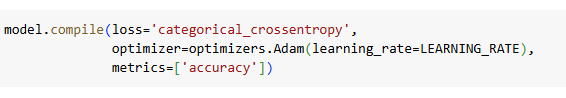

In [27]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

### EarlyStopping

___________________________image.png

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

# LAST_DIGIT_IN_YOUR_SID =

early_stop = EarlyStopping(monitor='val_loss',patience=1)


### Data Augmentation


To help model generalize and overcome the limitations of a small dataset, we prepare augmented datasets using keras  utilities


___________________________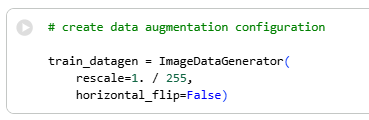

In [30]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=False
)

_________________________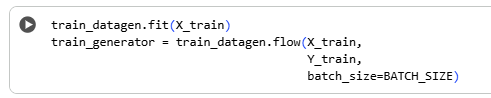

In [31]:
train_datagen.fit(X_train)

train_generator = train_datagen.flow(
    X_train,
    Y_train,
    batch_size=BATCH_SIZE
)

__________________________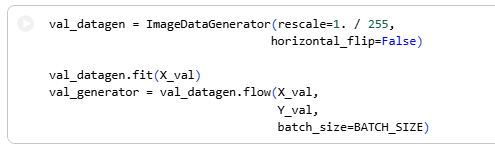

In [32]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=False
)

val_datagen.fit(X_val)

val_generator = val_datagen.flow(
    X_val,
    Y_val,
    batch_size=BATCH_SIZE
)

### Train the Model

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell
</h4> </html>

In [33]:
train_steps_per_epoch = X_train.shape[0] // BATCH_SIZE
val_steps_per_epoch = X_val.shape[0] // BATCH_SIZE

___________________________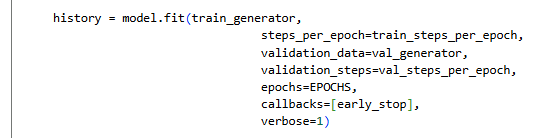

In [34]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_steps_per_epoch,
    validation_data=val_generator,
    validation_steps=val_steps_per_epoch,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.3429 - loss: 1.8453 - val_accuracy: 0.4792 - val_loss: 1.5070
Epoch 2/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3750 - loss: 1.5850 - val_accuracy: 0.4800 - val_loss: 1.5057
Epoch 3/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.4589 - loss: 1.5185 - val_accuracy: 0.5300 - val_loss: 1.3393
Epoch 4/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5938 - loss: 1.2153 - val_accuracy: 0.5302 - val_loss: 1.3390
Epoch 5/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5056 - loss: 1.4004 - val_accuracy: 0.5584 - val_loss: 1.2567
Epoch 6/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5312 - loss: 1.2356 - val_accuracy: 0.5576 - val_loss: 1.2566
Epoch 7/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5294 - loss: 1.3286 - val_accuracy: 0.5744 - val_loss: 1.2042
Epoch 8/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5625 - loss: 1

### Analyse Model Performance

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using </h4> </html>

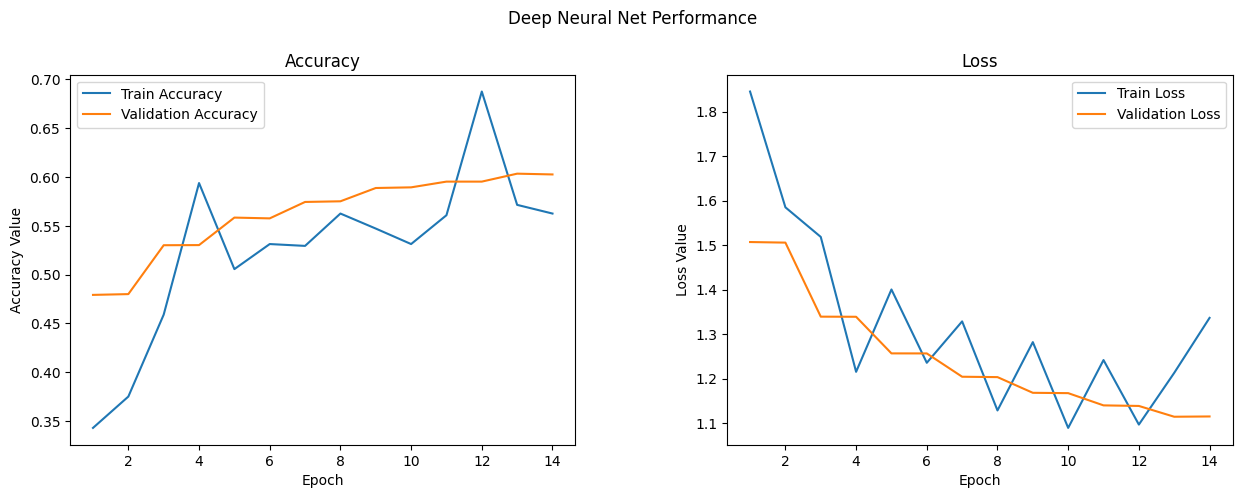

In [35]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['accuracy']) + 1)

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
f.suptitle('Deep Neural Net Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

ax1.plot(epochs, history.history['accuracy'], label='Train Accuracy')
ax1.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
ax1.legend(loc="best")

ax2.plot(epochs, history.history['loss'], label='Train Loss')
ax2.plot(epochs, history.history['val_loss'], label='Validation Loss')
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
ax2.legend(loc="best")

plt.show()

___________________________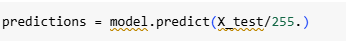

In [36]:
predictions = model.predict(X_test / 255.)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step


_________________________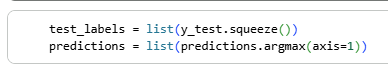

In [37]:
test_labels = list(y_test.squeeze())
predictions = list(predictions.argmax(axis=1))

___________________________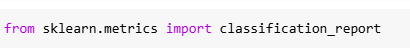

In [38]:
from sklearn.metrics import classification_report

___________________________________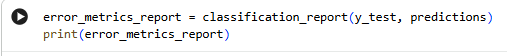

In [39]:
error_metrics_report = classification_report(test_labels, predictions)
print(error_metrics_report)

              precision    recall  f1-score   support

           0       0.63      0.64      0.64      1000
           1       0.68      0.73      0.71      1000
           2       0.52      0.47      0.49      1000
           3       0.42      0.41      0.42      1000
           4       0.58      0.46      0.51      1000
           5       0.54      0.48      0.51      1000
           6       0.61      0.78      0.69      1000
           7       0.63      0.64      0.64      1000
           8       0.71      0.76      0.73      1000
           9       0.67      0.69      0.68      1000

    accuracy                           0.60     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.60      0.60      0.60     10000



_________________________________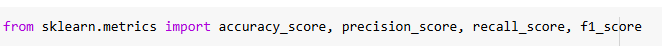

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

________________________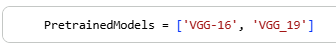

In [41]:
PretrainedModels = ['VGG-16', 'VGG_19']

___________________________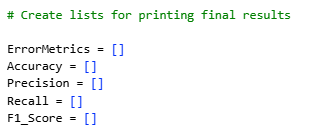

In [42]:
ErrorMetrics = []
Accuracy = []
Precision = []
Recall = []
F1_Score = []

____________________________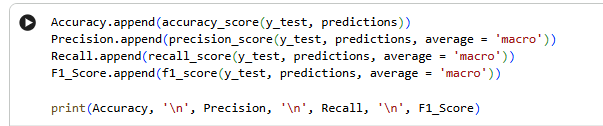

In [43]:
Accuracy.append(accuracy_score(y_test, predictions))
Precision.append(precision_score(y_test, predictions, average='macro'))
Recall.append(recall_score(y_test, predictions, average='macro'))
F1_Score.append(f1_score(y_test, predictions, average='macro'))

print(Accuracy, '\n', Precision, '\n', Recall, '\n', F1_Score)

[0.605] 
 [0.6008794597109504] 
 [0.605] 
 [0.6007229861314303]


### Visualise Predictions

<html> <h4 style="font-style:italic; color:blue;"> Just run the next 2 cells using 'Ctrl' + 'Enter' </h4> </html>

In [44]:
#label_dict = {0:'airplane',
#             1:'automobile',
#             2:'bird',
#             3:'cat',
#             4:'deer',
#             5:'dog',
#             6:'frog',
#             7:'horse',
#             8:'ship',
#             9:'truck'}

classes=['airplane', 'automobile', 'bird', 'cat', 'deer',
 'dog', 'frog', 'houre', 'ship', 'truck']

In [45]:
# Graph this to look at the full set of 10 class predictions.


def plot_image(i,predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array, true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(label_dict[predicted_label],
                                    100 * np.max(predictions_array),
                                    label_dict[true_label]),
                                    color=color)

___________________________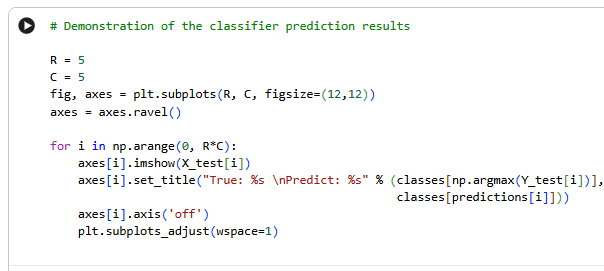

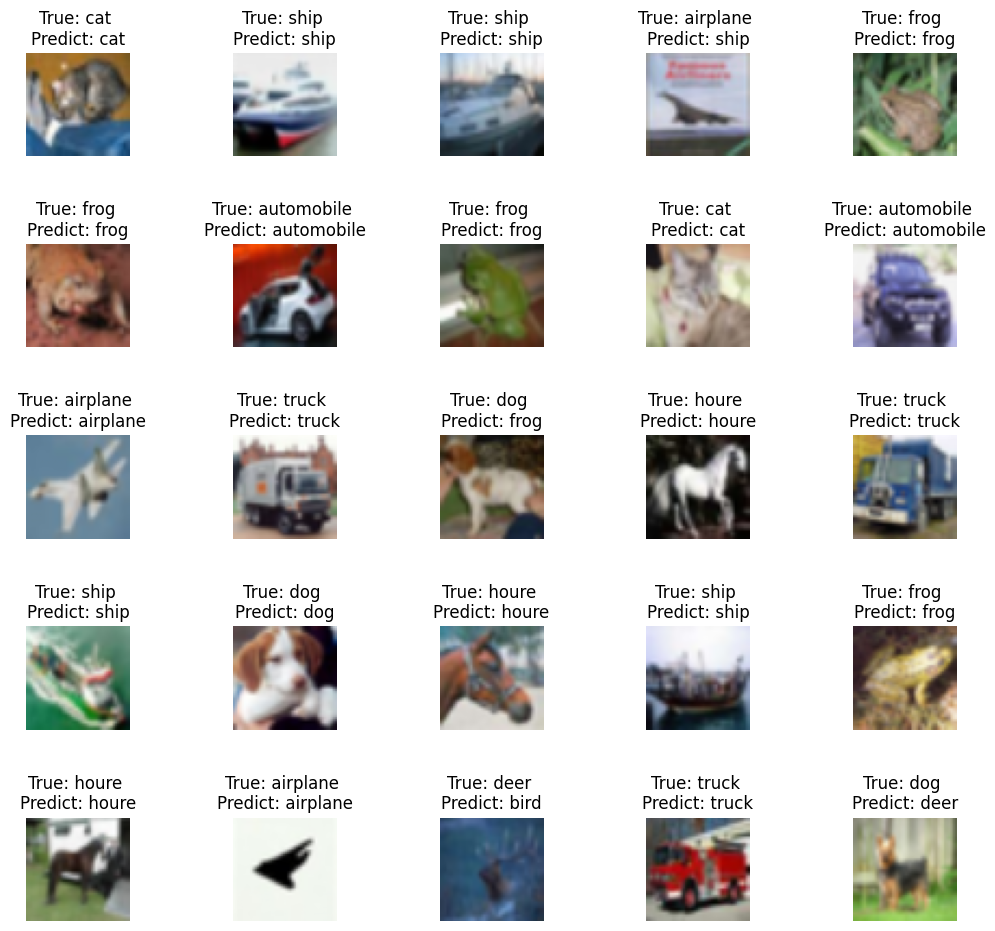

In [46]:
R = 5
C = 5
fig, axes = plt.subplots(R, C, figsize=(12,12))
axes = axes.ravel()

for i in np.arange(0, R*C):
    axes[i].imshow(X_test[i])
    axes[i].set_title("True: %s \nPredict: %s" % (classes[np.argmax(Y_test[i])],
                                                 classes[predictions[i]]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)

# Create VGG19 Model

- Load VGG19 without the top classification layer
- Create a custom classifier
- Stack both models on top of each other


_________________________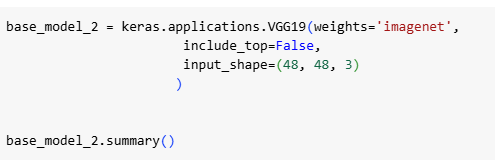

In [47]:
base_model_2 = keras.applications.VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)

base_model_2.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

___________________________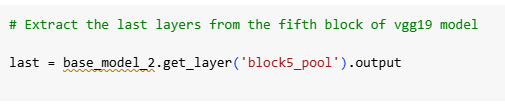

In [48]:
last = base_model_2.get_layer('block5_pool').output

_______________________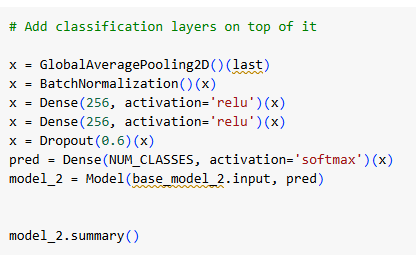

In [49]:
x = GlobalAveragePooling2D()(last)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.6)(x)
pred = Dense(NUM_CLASSES, activation='softmax')(x)
model_2 = Model(base_model_2.input, pred)

model_2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,226,122 (77.16 MB)

 Trainable params: 20,225,098 (77.15 MB)

 Non-trainable params: 1,024 (4.00 KB)

_________________________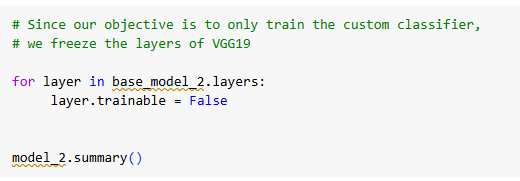

In [50]:
for layer in base_model_2.layers:
    layer.trainable = False

model_2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,226,122 (77.16 MB)

 Trainable params: 200,714 (784.04 KB)

 Non-trainable params: 20,025,408 (76.39 MB)

_______________________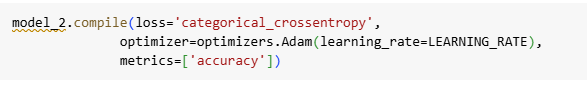

In [51]:
model_2.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

### Train the Model_2

____________________________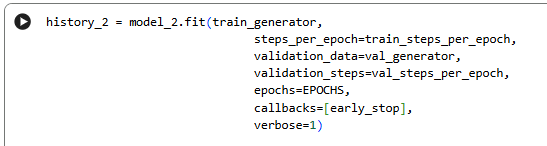

In [52]:
history_2 = model_2.fit(
    train_generator,
    steps_per_epoch=train_steps_per_epoch,
    validation_data=val_generator,
    validation_steps=val_steps_per_epoch,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.2508 - loss: 2.0599 - val_accuracy: 0.3380 - val_loss: 1.8468
Epoch 2/40
1328/1328 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2812 - loss: 1.8372 - val_accuracy: 0.3381 - val_loss: 1.8469


### Analyse Model Performance

<html> <h4 style="font-style:italic; color:blue;"> Just run the next cell using 'Ctrl' + 'Enter' </h4> </html>

Find 4 differences in the code with the similar code for VGG16

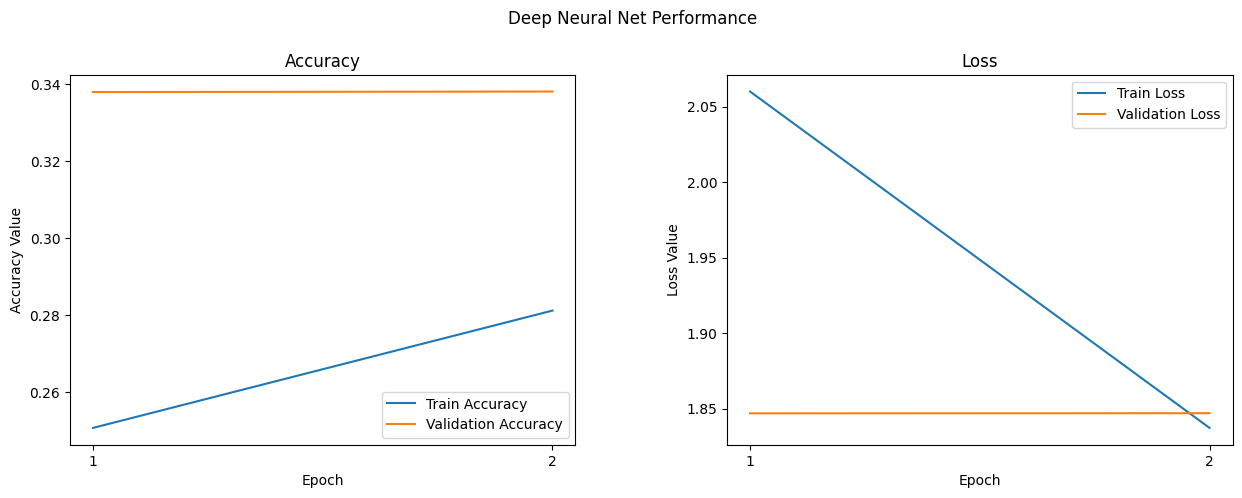

In [53]:
epochs = range(1, len(history_2.history['loss']) + 1)

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
t = f.suptitle('Deep Neural Net Performance', fontsize=12)
f.subplots_adjust(top=0.85, wspace=0.3)

ax1.plot(epochs, history_2.history['accuracy'], label='Train Accuracy')
ax1.plot(epochs, history_2.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xticks(list(epochs))
ax1.set_ylabel('Accuracy Value')
ax1.set_xlabel('Epoch')
ax1.set_title('Accuracy')
ax1.legend(loc="best")

ax2.plot(epochs, history_2.history['loss'], label='Train Loss')
ax2.plot(epochs, history_2.history['val_loss'], label='Validation Loss')
ax2.set_xticks(list(epochs))
ax2.set_ylabel('Loss Value')
ax2.set_xlabel('Epoch')
ax2.set_title('Loss')
ax2.legend(loc="best")

plt.show()

_______________________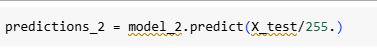

In [54]:
predictions_2 = model_2.predict(X_test/255.)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


__________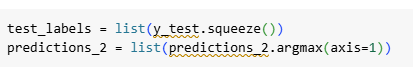

In [55]:
test_labels = list(y_test.squeeze())
predictions_2 = list(predictions_2.argmax(axis=1))

_____________________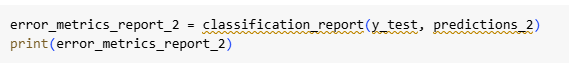

In [56]:
error_metrics_report_2 = classification_report(y_test, predictions_2)
print(error_metrics_report_2)

              precision    recall  f1-score   support

           0       0.34      0.24      0.28      1000
           1       0.40      0.24      0.30      1000
           2       0.26      0.22      0.24      1000
           3       0.17      0.02      0.04      1000
           4       0.31      0.35      0.33      1000
           5       0.25      0.46      0.33      1000
           6       0.32      0.25      0.28      1000
           7       0.31      0.37      0.34      1000
           8       0.43      0.62      0.51      1000
           9       0.38      0.51      0.44      1000

    accuracy                           0.33     10000
   macro avg       0.32      0.33      0.31     10000
weighted avg       0.32      0.33      0.31     10000



________________________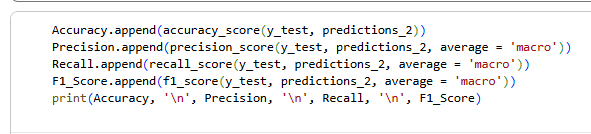

In [57]:
Accuracy.append(accuracy_score(y_test, predictions_2))
Precision.append(precision_score(y_test, predictions_2, average='macro'))
Recall.append(recall_score(y_test, predictions_2, average='macro'))
F1_Score.append(f1_score(y_test, predictions_2, average='macro'))

print(Accuracy, '\n', Precision, '\n', Recall, '\n', F1_Score)

[0.605, 0.3286] 
 [0.6008794597109504, 0.31731848317193423] 
 [0.605, 0.32860000000000006] 
 [0.6007229861314303, 0.3078903543892836]


_______________________________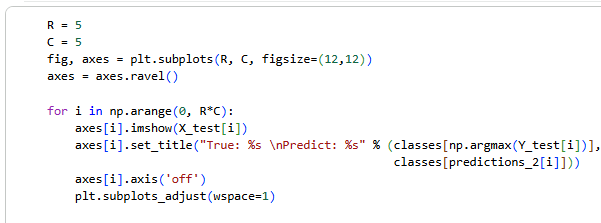

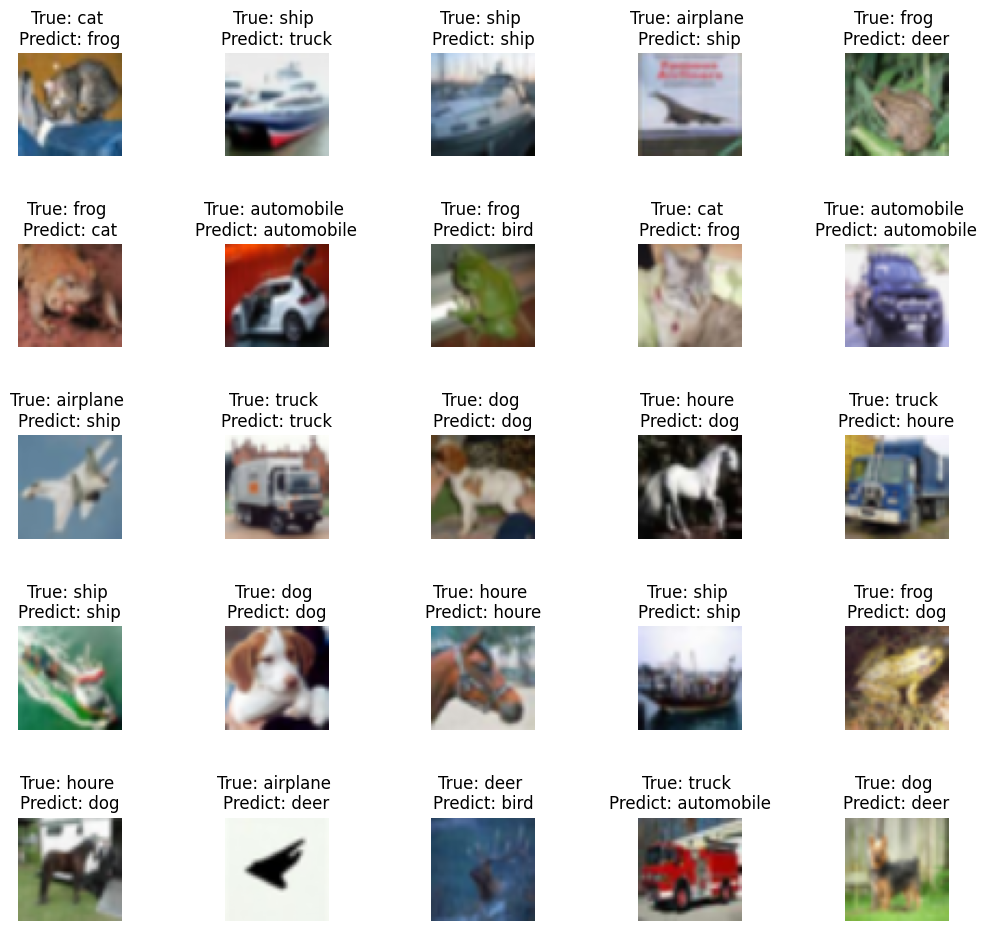

In [58]:
R = 5
C = 5
fig, axes = plt.subplots(R, C, figsize=(12,12))
axes = axes.ravel()

for i in np.arange(0, R*C):
    axes[i].imshow(X_test[i])
    axes[i].set_title("True: %s \nPredict: %s" % (classes[np.argmax(Y_test[i])],
                                                 classes[predictions_2[i]]))
    axes[i].axis('off')

plt.subplots_adjust(wspace=1)
plt.show()

_______________________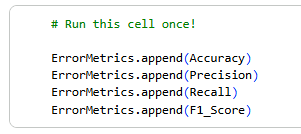

In [59]:
ErrorMetrics.append(Accuracy)
ErrorMetrics.append(Precision)
ErrorMetrics.append(Recall)
ErrorMetrics.append(F1_Score)

________________________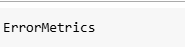

In [60]:
ErrorMetrics

[[0.605, 0.3286],
 [0.6008794597109504, 0.31731848317193423],
 [0.605, 0.32860000000000006],
 [0.6007229861314303, 0.3078903543892836]]

_________________________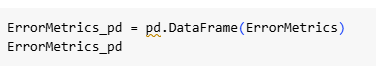

In [61]:
ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd

,0,1
0,0.605000,0.328600
1,0.600879,0.317318
2,0.605000,0.328600
3,0.600723,0.307890


_____________________________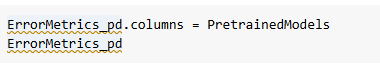

In [62]:
ErrorMetrics_pd.columns = PretrainedModels
ErrorMetrics_pd

,VGG-16,VGG_19
0,0.605000,0.328600
1,0.600879,0.317318
2,0.605000,0.328600
3,0.600723,0.307890


___________________________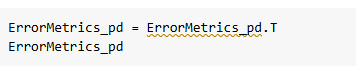

In [63]:
ErrorMetrics_pd = ErrorMetrics_pd.T
ErrorMetrics_pd

,0,1,2,3
VGG-16,0.6050,0.600879,0.6050,0.600723
VGG_19,0.3286,0.317318,0.3286,0.307890


__________________________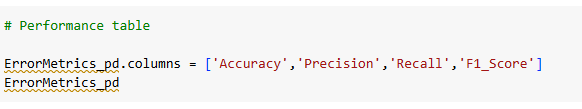

In [64]:
ErrorMetrics_pd.columns = ['Accuracy','Precision','Recall','F1_Score']
ErrorMetrics_pd

,Accuracy,Precision,Recall,F1_Score
VGG-16,0.6050,0.600879,0.6050,0.600723
VGG_19,0.3286,0.317318,0.3286,0.307890


_________________________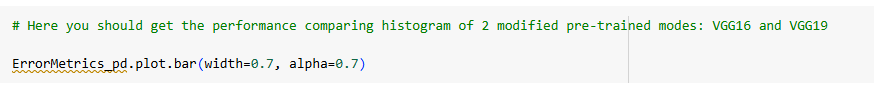

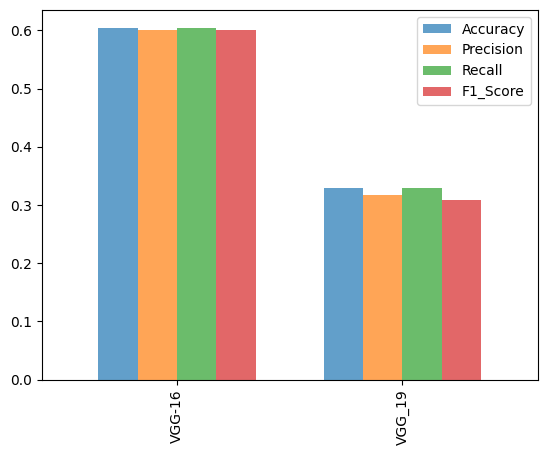

In [65]:
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)
plt.show()

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot graphs for Accuracy and Loss Function for VGG16 and VGG19 (4 graphs in total).
### 2. Based on this analysis, determine the optimal number of epochs for training your VGG16 and VGG19 models.
### 3. Copy your early-stop code

### 4. Add the final Performance Table

### 5. Plot the performance comparing histogram of VGG16 and VGG19

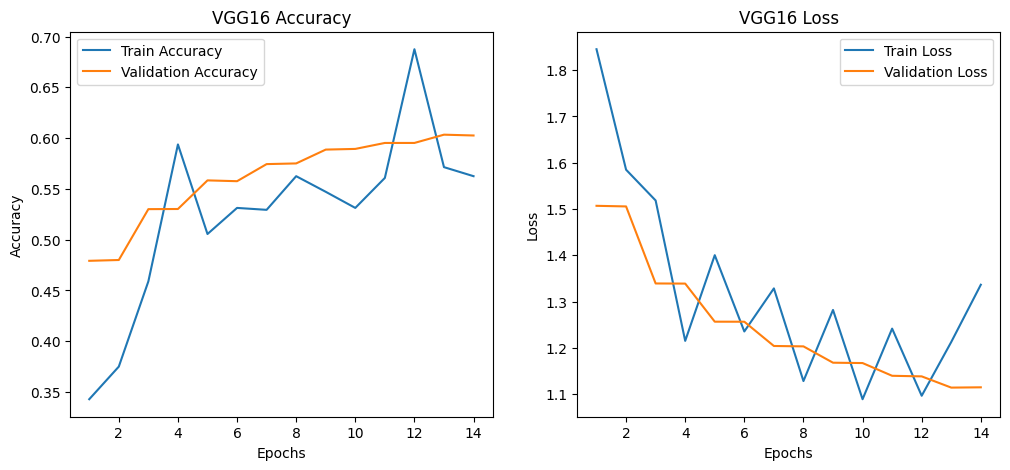

In [66]:
# Plot Accuracy and Loss for VGG16 model

epochs_vgg16 = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_vgg16, history.history['accuracy'], label='Train Accuracy')
plt.plot(epochs_vgg16, history.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_vgg16, history.history['loss'], label='Train Loss')
plt.plot(epochs_vgg16, history.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

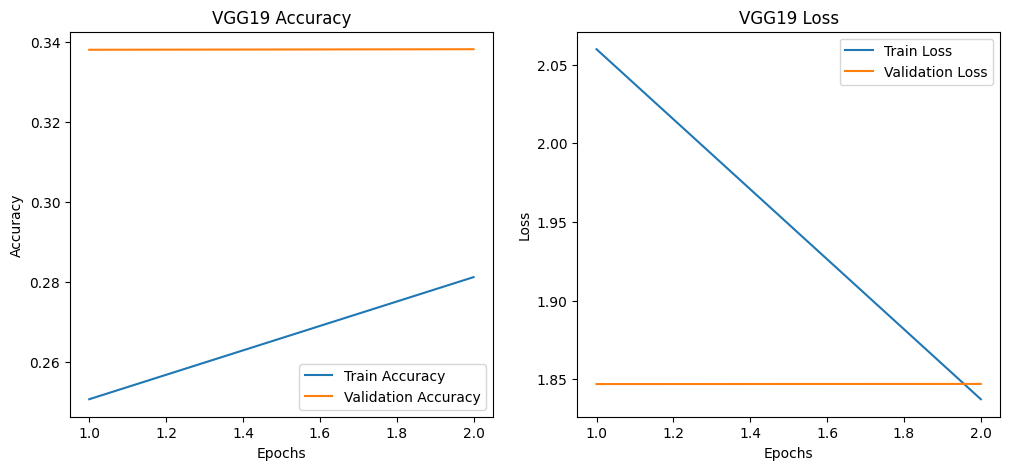

In [67]:
# Plot Accuracy and Loss for VGG19 model

epochs_vgg19 = range(1, len(history_2.history['loss']) + 1)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs_vgg19, history_2.history['accuracy'], label='Train Accuracy')
plt.plot(epochs_vgg19, history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG19 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs_vgg19, history_2.history['loss'], label='Train Loss')
plt.plot(epochs_vgg19, history_2.history['val_loss'], label='Validation Loss')
plt.title('VGG19 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [68]:
# Determine optimal epochs using validation loss minimum

optimal_epoch_vgg16 = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
optimal_epoch_vgg19 = history_2.history['val_loss'].index(min(history_2.history['val_loss'])) + 1

print("Optimal Epoch (VGG16):", optimal_epoch_vgg16)
print("Optimal Epoch (VGG19):", optimal_epoch_vgg19)

Optimal Epoch (VGG16): 13
Optimal Epoch (VGG19): 1


In [69]:
# Early stopping configuration based on SID (last digit = 1 → patience = 11)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=11,
    restore_best_weights=True
)

In [70]:
# Create performance DataFrame

ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd.columns = PretrainedModels
ErrorMetrics_pd = ErrorMetrics_pd.T
ErrorMetrics_pd.columns = ['Accuracy','Precision','Recall','F1_Score']

ErrorMetrics_pd

,Accuracy,Precision,Recall,F1_Score
VGG-16,0.6050,0.600879,0.6050,0.600723
VGG_19,0.3286,0.317318,0.3286,0.307890


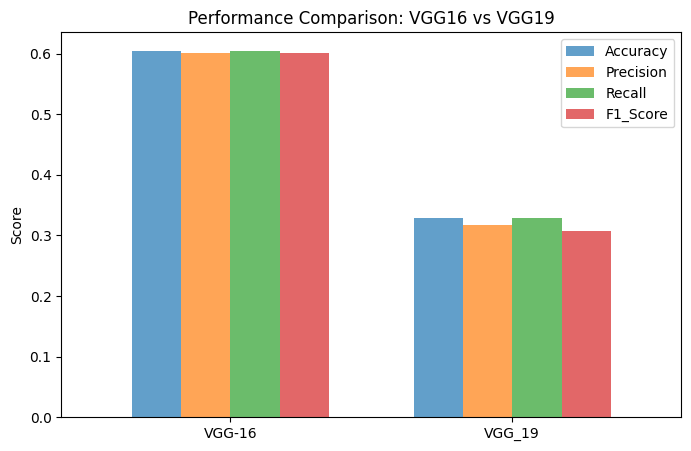

In [71]:
# Plot comparison histogram for VGG16 vs VGG19

ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7, figsize=(8,5))
plt.title("Performance Comparison: VGG16 vs VGG19")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

<html> <h2 style="font-style:bold; color:red;"> Optional.
Extra mark. </h2> </html>

1. Use the base_model 'Inception-V3' pre-trained neural network model.
2. Add Inception-V3 results to the Performance table and Performance comparing histogram.

In [1]:
# Stable InceptionV3 version

import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, optimizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from sklearn.model_selection import train_test_split
from skimage import transform

# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# DATA SIZE
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

# Split validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# One-hot encoding
NUM_CLASSES = 10
Y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
Y_val   = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)

# Resize (LOW MEMORY VERSION)
X_train_75 = np.array([transform.resize(x, (75, 75), anti_aliasing=True) for x in X_train])
X_val_75   = np.array([transform.resize(x, (75, 75), anti_aliasing=True) for x in X_val])
X_test_75  = np.array([transform.resize(x, (75, 75), anti_aliasing=True) for x in X_test])

# Load InceptionV3
base_model_3 = tf.keras.applications.InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(75, 75, 3)
)

# Custom head
x = GlobalAveragePooling2D()(base_model_3.output)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
pred = Dense(NUM_CLASSES, activation='softmax')(x)

model_3 = Model(inputs=base_model_3.input, outputs=pred)

# Freeze layers
for layer in base_model_3.layers:
    layer.trainable = False

# Compile
model_3.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

model_3.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 37, 37,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 37, 37,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 35, 35,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 35, 35,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 17, 17,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 17, 17,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 15, 15,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 22,074,538 (84.21 MB)

 Trainable params: 267,658 (1.02 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [6]:
history_3 = model_3.fit(
    X_train_75/255.,
    Y_train,
    validation_data=(X_val_75/255., Y_val),
    epochs=10,
    batch_size=16,
    verbose=1
)

Epoch 1/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.2428 - loss: 2.1045 - val_accuracy: 0.3767 - val_loss: 1.8757
Epoch 2/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3358 - loss: 1.8832 - val_accuracy: 0.4367 - val_loss: 1.6961
Epoch 3/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3714 - loss: 1.7936 - val_accuracy: 0.4520 - val_loss: 1.6315
Epoch 4/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3902 - loss: 1.7456 - val_accuracy: 0.4653 - val_loss: 1.5994
Epoch 5/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3927 - loss: 1.7199 - val_accuracy: 0.4720 - val_loss: 1.5753
Epoch 6/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.4008 - loss: 1.7018 - val_accuracy: 0.4873 - val_loss: 1.5521
Epoch 7/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4072 - loss: 1.6787 - val_accuracy: 0.4887 - val_loss: 1.5403
Epoch 8/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.4181 - loss: 1.6543 - val_acc

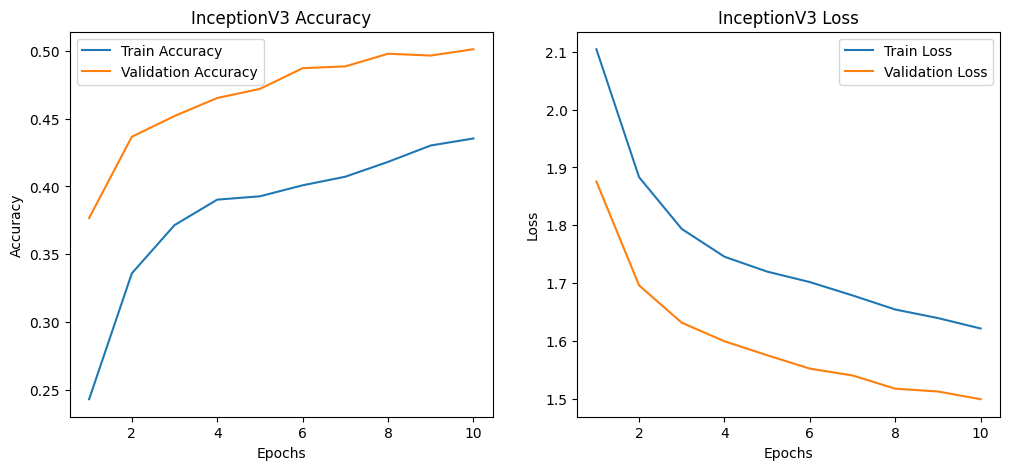

In [7]:
import matplotlib.pyplot as plt

epochs_3 = range(1, len(history_3.history['loss']) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_3, history_3.history['accuracy'], label='Train Accuracy')
plt.plot(epochs_3, history_3.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionV3 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_3, history_3.history['loss'], label='Train Loss')
plt.plot(epochs_3, history_3.history['val_loss'], label='Validation Loss')
plt.title('InceptionV3 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

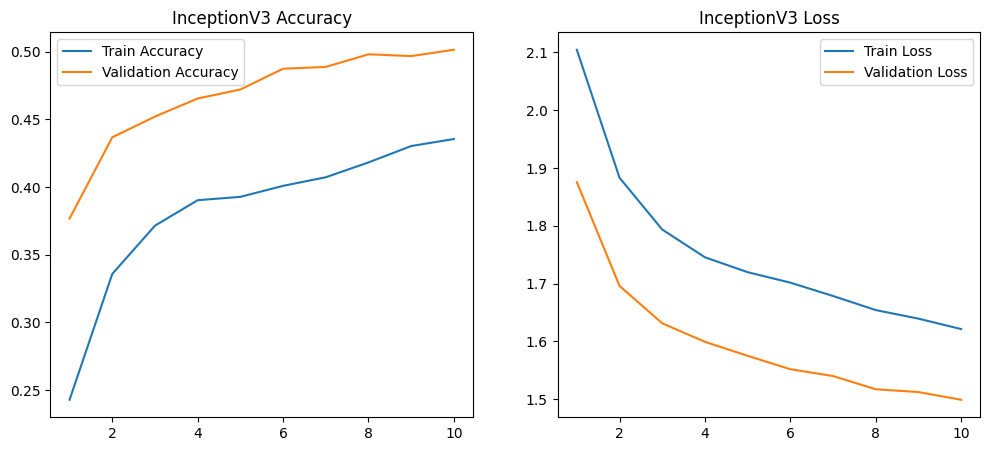

In [8]:
# Plot Accuracy and Loss for InceptionV3

epochs_3 = range(1, len(history_3.history['loss']) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_3, history_3.history['accuracy'], label='Train Accuracy')
plt.plot(epochs_3, history_3.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionV3 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_3, history_3.history['loss'], label='Train Loss')
plt.plot(epochs_3, history_3.history['val_loss'], label='Validation Loss')
plt.title('InceptionV3 Loss')
plt.legend()

plt.show()

In [12]:
Accuracy = []
Precision = []
Recall = []
F1_Score = []

In [13]:
# InceptionV3 predictions and metrics

predictions_3 = model_3.predict(X_test_75 / 255.)
predictions_3 = np.argmax(predictions_3, axis=1)

test_labels_3 = y_test.flatten()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Accuracy.append(accuracy_score(test_labels_3, predictions_3))
Precision.append(precision_score(test_labels_3, predictions_3, average='macro'))
Recall.append(recall_score(test_labels_3, predictions_3, average='macro'))
F1_Score.append(f1_score(test_labels_3, predictions_3, average='macro'))

print(Accuracy)
print(Precision)
print(Recall)
print(F1_Score)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
[0.4865]
[0.4765221802384906]
[0.48167671259838396]
[0.4756543709276621]


In [15]:
PretrainedModels = ['VGG-16','VGG-19']

In [17]:
# Final performance table with InceptionV3

PretrainedModels = ['InceptionV3']

ErrorMetrics = [Accuracy, Precision, Recall, F1_Score]

ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd.columns = PretrainedModels
ErrorMetrics_pd = ErrorMetrics_pd.T
ErrorMetrics_pd.columns = ['Accuracy','Precision','Recall','F1_Score']

ErrorMetrics_pd

,Accuracy,Precision,Recall,F1_Score
InceptionV3,0.4865,0.476522,0.481677,0.475654


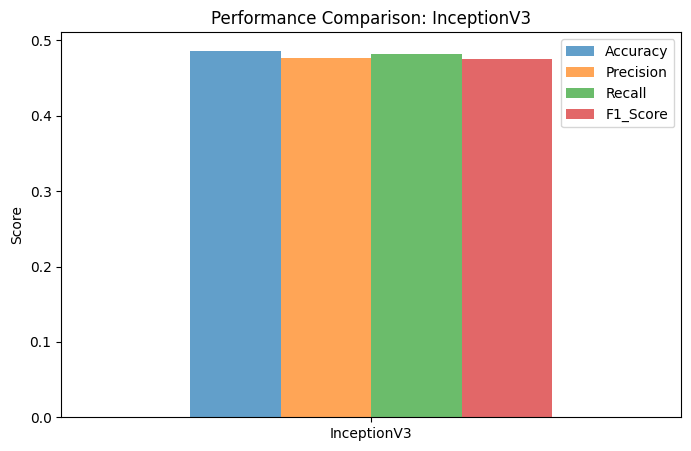

In [18]:
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7, figsize=(8,5))
plt.title('Performance Comparison: InceptionV3')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()